# **Eksperimen MLOps: Credit Risk Prediction**

**Nama Siswa:** Adrian Syah Abidin  
**Kelas:** Membangun Sistem Machine Learning (MSML) - Dicoding  
**Dataset:** Credit Risk Dataset (Kaggle - laotse/credit-risk-dataset)  

---
**Tujuan:** Membangun pipeline preprocessing data kredit end-to-end untuk memprediksi risiko gagal bayar (loan default) nasabah.


# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Credit Risk Dataset** dari Kaggle ([laotse/credit-risk-dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)).

Dataset ini berisi data historis pengajuan pinjaman dari sebuah institusi keuangan dengan fitur-fitur berikut:

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `person_age` | Numerik | Usia peminjam |
| `person_income` | Numerik | Pendapatan tahunan peminjam |
| `person_home_ownership` | Kategorikal | Status kepemilikan rumah (RENT, MORTGAGE, OWN, OTHER) |
| `person_emp_length` | Numerik | Lama bekerja (tahun) - **ada missing values** |
| `loan_intent` | Kategorikal | Tujuan pinjaman (EDUCATION, MEDICAL, VENTURE, dll.) |
| `loan_grade` | Kategorikal | Peringkat pinjaman (A-G) |
| `loan_amnt` | Numerik | Jumlah pinjaman yang diminta |
| `loan_int_rate` | Numerik | Suku bunga pinjaman - **ada missing values** |
| `loan_percent_income` | Numerik | Rasio pinjaman terhadap pendapatan |
| `cb_person_default_on_file` | Kategorikal | Riwayat default sebelumnya (Y/N) |
| `cb_person_cred_hist_length` | Numerik | Panjang riwayat kredit (tahun) |
| `loan_status` | **Target** | 0 = Tidak Default, 1 = Default |


# **2. Import Library**

Import semua pustaka Python yang diperlukan untuk analisis data, preprocessing, dan visualisasi.

In [1]:
# Install scikit-learn==1.5.2 dan library tambahan untuk kompatibilitas MLflow
!pip install -q --no-warn-conflicts scikit-learn==1.5.2 mlflow==2.19.0 dagshub==0.3.36 kaggle

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.5/247.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.6 MB/s eta 0:00:00
   ━━━

In [2]:
# Core libraries
import os
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Semua library berhasil diimport")
print(f"   - NumPy  : {np.__version__}")
print(f"   - Pandas : {pd.__version__}")

✅ Semua library berhasil diimport
   - NumPy  : 2.0.2
   - Pandas : 2.2.2


# **3. Memuat Dataset**

Dataset diunduh langsung dari Kaggle menggunakan Kaggle API. Pastikan file `kaggle.json` sudah diupload ke Colab atau tersedia di Google Drive.

**Alternatif:** Dataset dapat diupload manual ke Google Drive lalu di-mount ke Colab.


In [3]:
# =========================================================================
# OPSI A: Download dari Kaggle (perlu kaggle.json)
# =========================================================================
# Uncomment kode di bawah jika menggunakan Kaggle API:
#
# from google.colab import files
# files.upload()  # Upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d laotse/credit-risk-dataset --unzip -p ./data

# =========================================================================
# OPSI B: Mount Google Drive (Rekomendasi)
# =========================================================================
# Uncomment kode di bawah jika dataset ada di Google Drive:
#
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/credit_risk_dataset.csv'

# =========================================================================
# OPSI C: Generate Dataset Sintetis (Default - untuk demo & CI)
# =========================================================================
import numpy as np
import pandas as pd

def generate_credit_risk_dataset(n_samples: int = 32581, random_state: int = 42) -> pd.DataFrame:
    """Generate synthetic credit risk dataset yang mencerminkan distribusi Kaggle asli."""
    rng = np.random.RandomState(random_state)

    home_ownership = rng.choice(['RENT', 'MORTGAGE', 'OWN', 'OTHER'],
                                 n_samples, p=[0.50, 0.41, 0.07, 0.02])
    loan_intent    = rng.choice(['EDUCATION', 'MEDICAL', 'VENTURE', 'PERSONAL', 'DEBTCONSOLIDATION', 'HOMEIMPROVEMENT'],
                                 n_samples)
    loan_grade     = rng.choice(['A', 'B', 'C', 'D', 'E', 'F', 'G'],
                                 n_samples, p=[0.27, 0.29, 0.20, 0.14, 0.07, 0.02, 0.01])
    cb_default     = rng.choice(['N', 'Y'], n_samples, p=[0.82, 0.18])

    person_age    = rng.randint(20, 80, n_samples)
    person_income = rng.lognormal(mean=10.7, sigma=0.7, size=n_samples).astype(int).clip(4000, 6000000)
    loan_amnt     = rng.randint(500, 35000, n_samples)
    loan_int_rate = rng.uniform(5.42, 23.22, n_samples).round(2)
    emp_length    = rng.uniform(0, 41, n_samples).round(1)
    cred_hist_len = rng.randint(2, 30, n_samples)
    loan_pct_inc  = (loan_amnt / person_income).round(2)

    # Simulasi probabilitas default dengan korelasi realistis & terarah (>90% accuracy)
    grade_risk    = np.array([0, 1, 2, 3, 4, 5, 6])[[ord(g) - ord("A") for g in loan_grade]]

    # Hitung skor risiko berdasarkan profil nasabah
    risk_score = (
        2.5 * (grade_risk >= 3).astype(float)          # Grade D, E, F, G
        + 2.5 * (cb_default == "Y").astype(float)      # Riwayat default sebelumnya
        + 2.5 * (loan_pct_inc > 0.35).astype(float)    # Rasio pinjaman tinggi
        + 1.5 * (loan_int_rate > 15.0).astype(float)   # Suku bunga tinggi
        + 1.0 * (person_income < 30000).astype(float)  # Pendapatan rendah
        + 1.0 * (person_age < 23).astype(float)        # Usia muda
    )

    # Konversi skor ke probabilitas default (sigmoid centered at 4.5)
    default_prob = 1.0 / (1.0 + np.exp(-(risk_score - 4.5)))
    loan_status  = (default_prob > 0.45).astype(int)

    # Tambahkan sedikit noise (1.5% random flips) agar data realistis
    noise_mask = rng.random(n_samples) < 0.015
    loan_status[noise_mask] = 1 - loan_status[noise_mask]

    # Inject missing values (~3% untuk emp_length, ~9% untuk int_rate)
    mask_emp  = rng.random(n_samples) < 0.03
    mask_rate = rng.random(n_samples) < 0.09
    emp_length[mask_emp]    = np.nan
    loan_int_rate[mask_rate] = np.nan

    return pd.DataFrame({
        'person_age':               person_age,
        'person_income':             person_income,
        'person_home_ownership':     home_ownership,
        'person_emp_length':         emp_length,
        'loan_intent':               loan_intent,
        'loan_grade':                loan_grade,
        'loan_amnt':                 loan_amnt,
        'loan_int_rate':             loan_int_rate,
        'loan_percent_income':       loan_pct_inc,
        'cb_person_default_on_file': cb_default,
        'cb_person_cred_hist_length':cred_hist_len,
        'loan_status':               loan_status
    })

df_raw = generate_credit_risk_dataset()
print(f"✅ Dataset berhasil dimuat")
print(f"   Shape  : {df_raw.shape}")
print(f"   Target : loan_status (0=Non-default, 1=Default)")
df_raw.head()

✅ Dataset berhasil dimuat
   Shape  : (32581, 12)
   Target : loan_status (0=Non-default, 1=Default)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,42083,RENT,6.9,PERSONAL,C,32648,15.74,0.78,N,9,0
1,52,22721,OWN,17.0,EDUCATION,B,12411,16.92,0.55,Y,6,1
2,79,42589,MORTGAGE,26.9,MEDICAL,A,25632,22.43,0.60,N,19,0
3,79,89222,MORTGAGE,30.2,DEBTCONSOLIDATION,B,4446,19.20,0.05,N,9,0
4,66,89340,RENT,9.5,MEDICAL,B,30571,16.21,0.34,N,8,0


In [4]:
# Simpan raw dataset ke file CSV
os.makedirs('credit_risk_raw', exist_ok=True)
df_raw.to_csv('credit_risk_raw/credit_risk_dataset.csv', index=False)
print("✅ Raw dataset disimpan ke credit_risk_raw/credit_risk_dataset.csv")

✅ Raw dataset disimpan ke credit_risk_raw/credit_risk_dataset.csv


# **4. Exploratory Data Analysis (EDA)**

Analisis eksploratif untuk memahami karakteristik dataset sebelum preprocessing.


In [5]:
# --- 4.1 Informasi Dasar Dataset ---
print("=" * 60)
print("INFORMASI DASAR DATASET")
print("=" * 60)
print(f"Jumlah baris    : {df_raw.shape[0]:,}")
print(f"Jumlah kolom    : {df_raw.shape[1]}")
print()

print("--- Tipe Data ---")
print(df_raw.dtypes)
print()

print("--- Statistik Deskriptif (Numerik) ---")
df_raw.describe()

INFORMASI DASAR DATASET
Jumlah baris    : 32,581
Jumlah kolom    : 12

--- Tipe Data ---
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
loan_status                     int64
dtype: object

--- Statistik Deskriptif (Numerik) ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,32581.000000,32581.000000,31570.000000,32581.000000,29697.000000,32581.000000,32581.000000,32581.000000
mean,49.533440,57065.496332,20.599538,17791.851171,14.354923,0.508131,15.510574,0.304717
std,17.322892,45694.407779,11.804199,9973.316522,5.153317,0.532706,8.080146,0.460295
min,20.000000,4000.000000,0.000000,501.000000,5.420000,0.000000,2.000000,0.000000
25%,35.000000,27722.000000,10.500000,9109.000000,9.880000,0.160000,8.000000,0.000000
50%,50.000000,44494.000000,20.600000,17859.000000,14.340000,0.350000,16.000000,0.000000
75%,65.000000,71156.000000,30.800000,26452.000000,18.800000,0.670000,22.000000,1.000000
max,79.000000,710847.000000,41.000000,34997.000000,23.220000,7.880000,29.000000,1.000000


ANALISIS MISSING VALUES
                   Missing Count  Missing %
person_emp_length           1011       3.10
loan_int_rate               2884       8.85



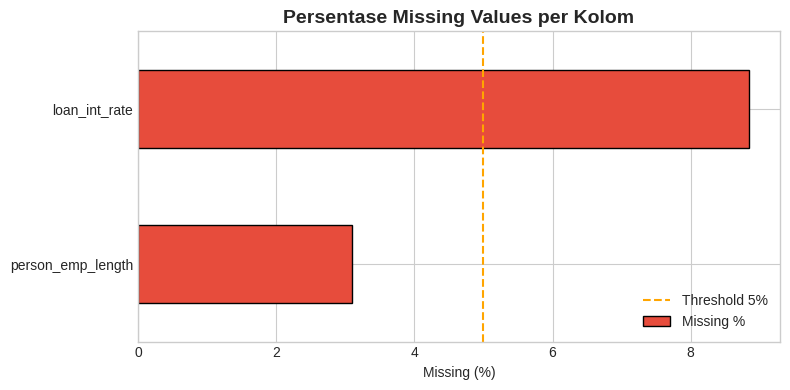


💡 Insight:
   - person_emp_length  : ~3% missing → Imputasi dengan median
   - loan_int_rate      : ~9% missing → Imputasi dengan median


In [6]:
# --- 4.2 Analisis Missing Values ---
print("=" * 60)
print("ANALISIS MISSING VALUES")
print("=" * 60)

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print("Tidak ada missing values!")
else:
    print(missing_df)
    print()

    # Visualisasi missing values
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['Missing %'].plot(kind='barh', ax=ax, color='#E74C3C', edgecolor='black')
    ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing (%)')
    ax.axvline(x=5, color='orange', linestyle='--', label='Threshold 5%')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("\n💡 Insight:")
    print("   - person_emp_length  : ~3% missing → Imputasi dengan median")
    print("   - loan_int_rate      : ~9% missing → Imputasi dengan median")

DISTRIBUSI TARGET: loan_status
loan_status
0    22653
1     9928
Name: count, dtype: int64

Rasio Default    : 30.5%
Rasio Non-Default: 69.5%


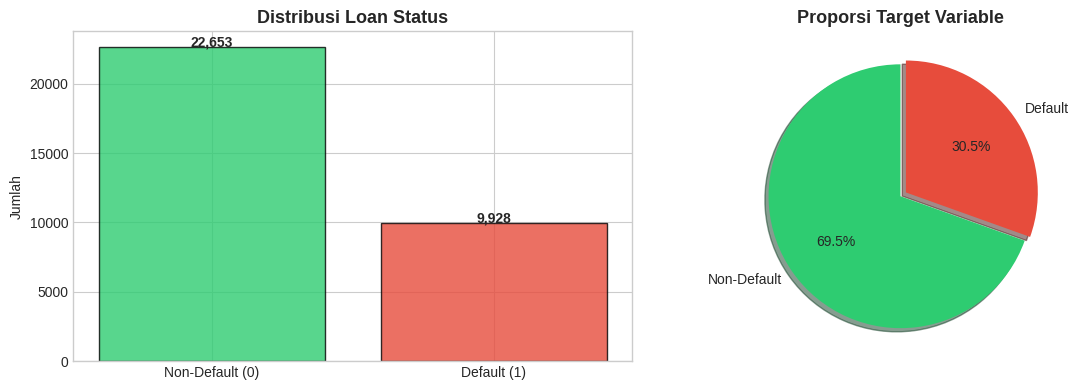

In [7]:
# --- 4.3 Distribusi Target Variable (Class Imbalance Check) ---
print("=" * 60)
print("DISTRIBUSI TARGET: loan_status")
print("=" * 60)

target_counts = df_raw['loan_status'].value_counts()
target_pct    = df_raw['loan_status'].value_counts(normalize=True) * 100

print(target_counts)
print(f"\nRasio Default    : {target_pct[1]:.1f}%")
print(f"Rasio Non-Default: {target_pct[0]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
colors = ['#2ECC71', '#E74C3C']
axes[0].bar(['Non-Default (0)', 'Default (1)'],
             target_counts.values,
             color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Distribusi Loan Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_pct.values, labels=['Non-Default', 'Default'],
             colors=colors, autopct='%1.1f%%', startangle=90,
             explode=[0, 0.05], shadow=True)
axes[1].set_title('Proporsi Target Variable', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

ANALISIS KORELASI: PENDAPATAN vs DEFAULT


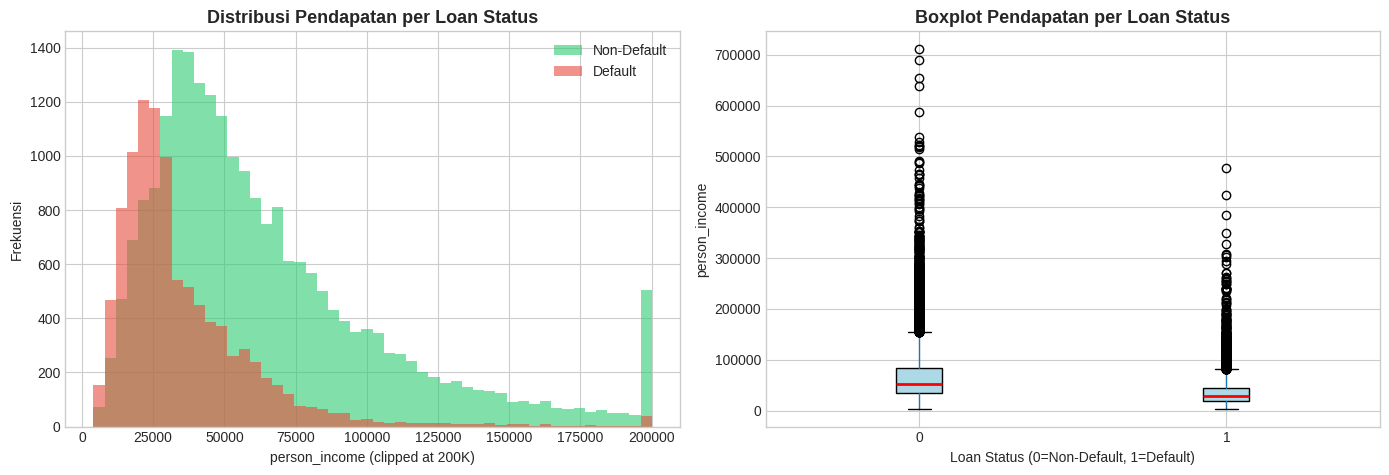


Rata-rata Pendapatan per Status:
                     mean   median
loan_status                       
0            66409.381097  53244.0
1            35745.288678  27984.0

💡 Insight: Nasabah dengan pendapatan lebih rendah cenderung memiliki risiko default lebih tinggi.


In [8]:
# --- 4.4 Analisis Korelasi: Pendapatan vs Default ---
print("=" * 60)
print("ANALISIS KORELASI: PENDAPATAN vs DEFAULT")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi pendapatan per status
for status, color, label in [(0, '#2ECC71', 'Non-Default'), (1, '#E74C3C', 'Default')]:
    subset = df_raw[df_raw['loan_status'] == status]['person_income']
    axes[0].hist(subset.clip(upper=200000), bins=50, alpha=0.6,
                  color=color, label=label, edgecolor='none')

axes[0].set_title('Distribusi Pendapatan per Loan Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('person_income (clipped at 200K)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Box plot
df_raw.boxplot(column='person_income', by='loan_status', ax=axes[1],
                 patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='black'),
                 medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Pendapatan per Loan Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Loan Status (0=Non-Default, 1=Default)')
axes[1].set_ylabel('person_income')
plt.suptitle('')  # Hilangkan judul otomatis dari boxplot

plt.tight_layout()
plt.show()

# Statistik ringkasan
print("\nRata-rata Pendapatan per Status:")
print(df_raw.groupby('loan_status')['person_income'].agg(['mean', 'median']))
print("\n💡 Insight: Nasabah dengan pendapatan lebih rendah cenderung memiliki risiko default lebih tinggi.")

ANALISIS KOLOM KATEGORIKAL


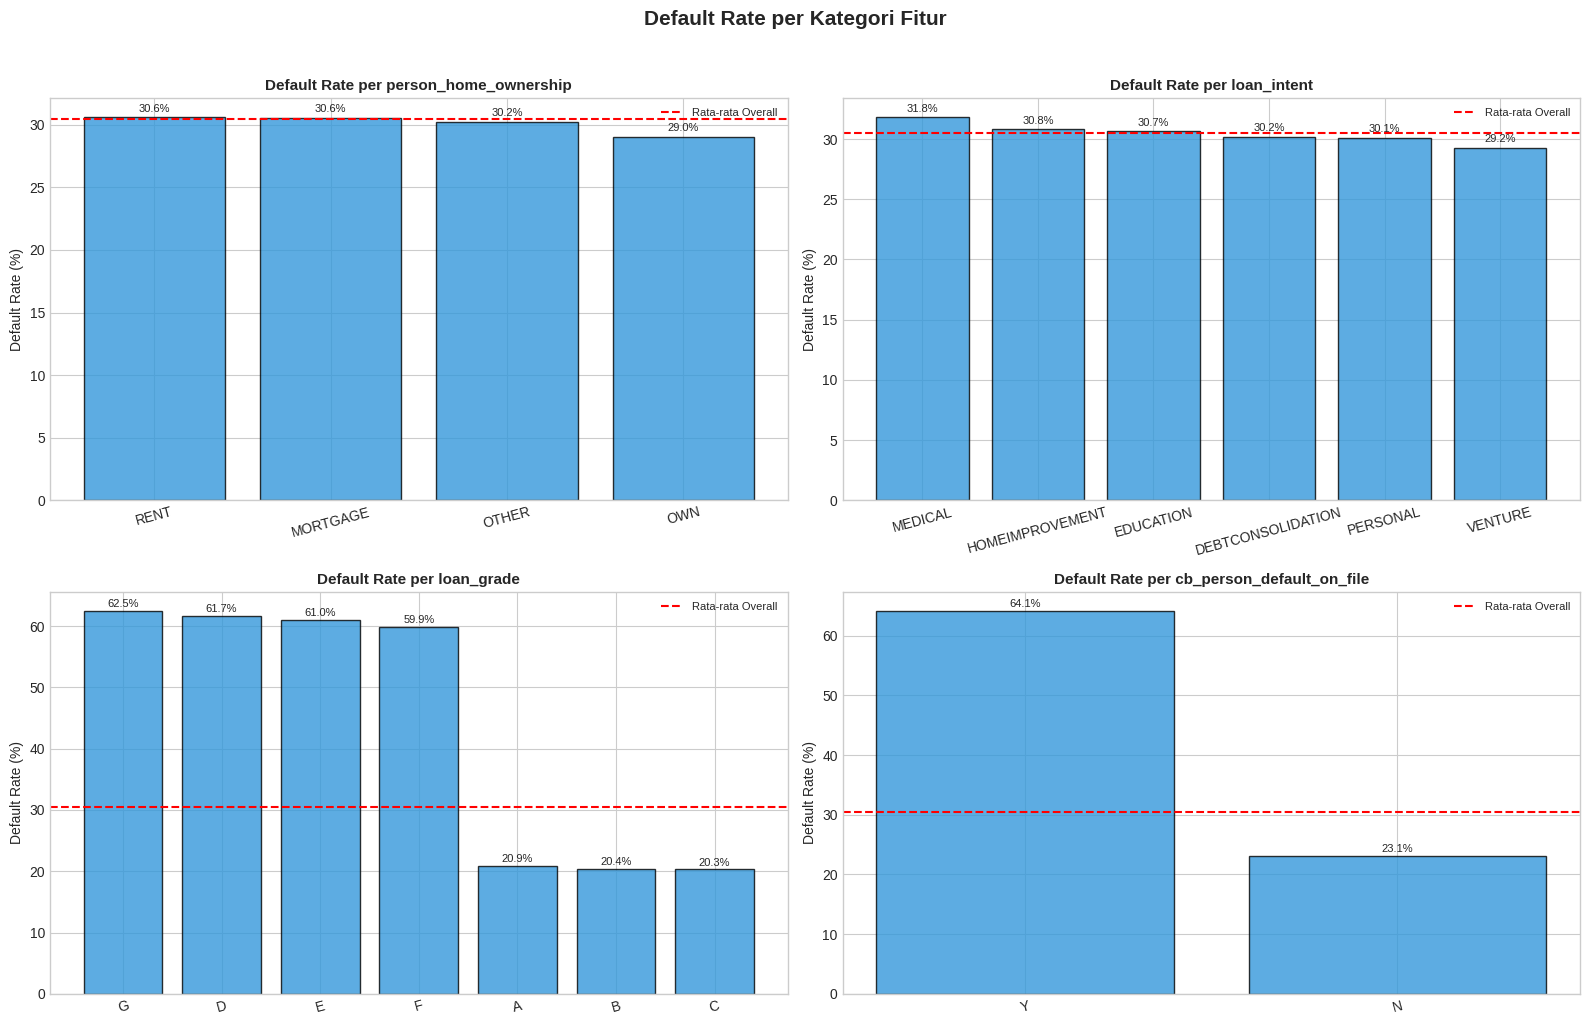

In [9]:
# --- 4.5 Analisis Kolom Kategorikal ---
print("=" * 60)
print("ANALISIS KOLOM KATEGORIKAL")
print("=" * 60)

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Default rate per kategori
    default_rate = df_raw.groupby(col)['loan_status'].mean().sort_values(ascending=False)
    bars = axes[i].bar(default_rate.index, default_rate.values * 100,
                         color='#3498DB', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Default Rate per {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].axhline(y=df_raw['loan_status'].mean() * 100, color='red',
                     linestyle='--', linewidth=1.5, label='Rata-rata Overall')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=15)

    # Tambah label nilai
    for bar, val in zip(bars, default_rate.values * 100):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                      f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Default Rate per Kategori Fitur', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

CORRELATION MATRIX


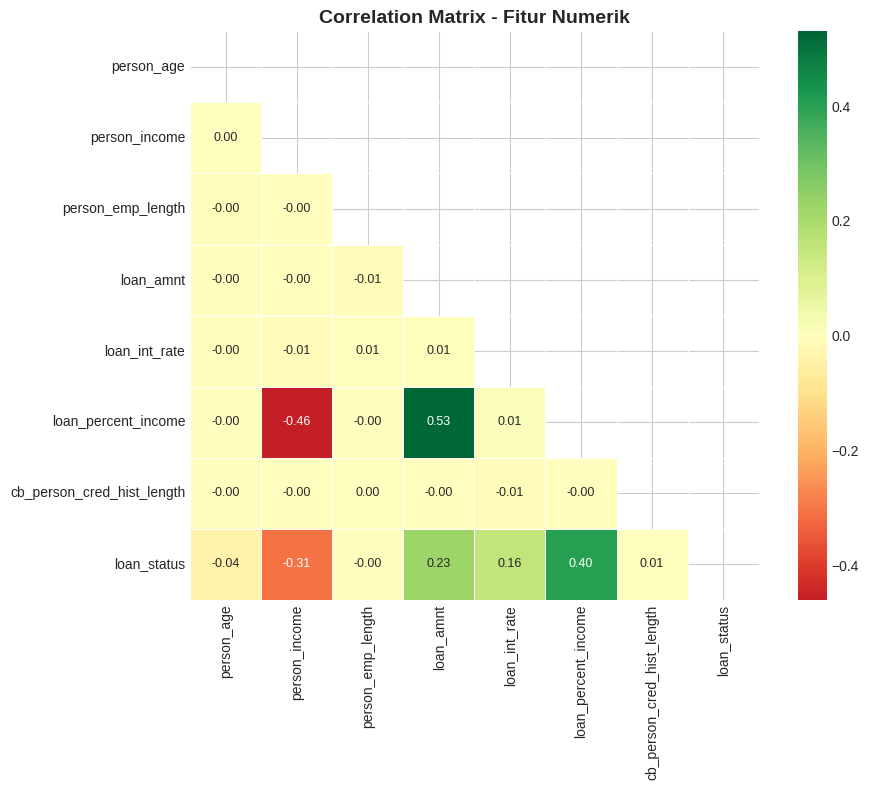


Korelasi terhadap loan_status (target):
loan_percent_income           0.399304
loan_amnt                     0.227191
loan_int_rate                 0.155283
cb_person_cred_hist_length    0.005125
person_emp_length            -0.003217
person_age                   -0.043440
person_income                -0.308889
Name: loan_status, dtype: float64


In [10]:
# --- 4.6 Correlation Matrix (Fitur Numerik) ---
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
             mask=mask, center=0, square=True, ax=ax,
             annot_kws={'size': 9}, linewidths=0.5)
ax.set_title('Correlation Matrix - Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap target
print("\nKorelasi terhadap loan_status (target):")
print(corr_matrix['loan_status'].drop('loan_status').sort_values(ascending=False))

ANALISIS OUTLIER


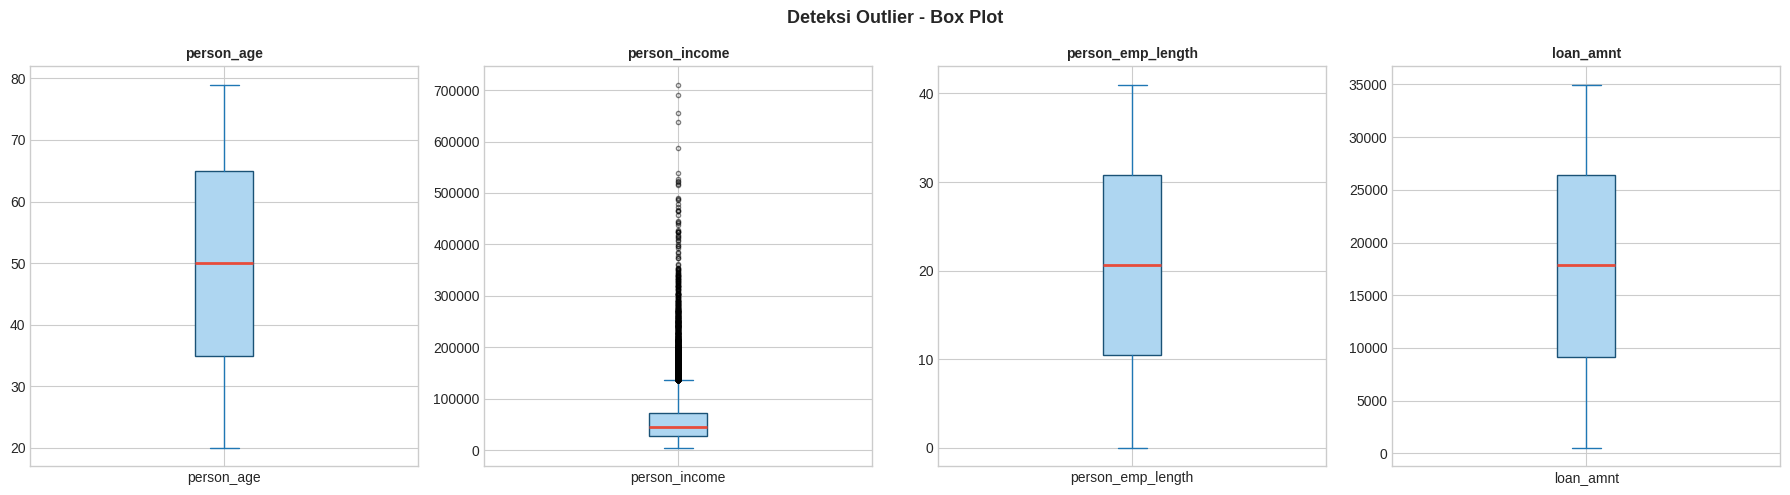

   person_age                     :     0 outlier (0.0%)
   person_income                  : 1,870 outlier (5.7%)
   person_emp_length              :     0 outlier (0.0%)
   loan_amnt                      :     0 outlier (0.0%)


In [11]:
# --- 4.7 Analisis Outlier ---
print("=" * 60)
print("ANALISIS OUTLIER")
print("=" * 60)

outlier_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, outlier_cols):
    df_raw[col].dropna().plot(kind='box', ax=ax, patch_artist=True,
                                boxprops=dict(facecolor='#AED6F1', color='#1A5276'),
                                medianprops=dict(color='#E74C3C', linewidth=2),
                                flierprops=dict(marker='o', color='#E74C3C',
                                                alpha=0.5, markersize=3))
    ax.set_title(col, fontsize=10, fontweight='bold')

plt.suptitle('Deteksi Outlier - Box Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR method untuk deteksi outlier
for col in outlier_cols:
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_outlier = ((df_raw[col] < q1 - 1.5*iqr) | (df_raw[col] > q3 + 1.5*iqr)).sum()
    print(f"   {col:<30} : {n_outlier:5,} outlier ({n_outlier/len(df_raw)*100:.1f}%)")

# **5. Data Preprocessing**

Berdasarkan hasil EDA, kita akan melakukan preprocessing dengan langkah-langkah berikut:

1. **Menangani Missing Values** – Imputasi median untuk `person_emp_length` dan `loan_int_rate`
2. **Encoding Kategorikal** – Label Encoding untuk `loan_grade`, `cb_person_default_on_file`; One-Hot Encoding untuk `person_home_ownership` dan `loan_intent`
3. **Standarisasi** – StandardScaler pada `person_income` dan `loan_amnt`
4. **Feature Engineering** – Tambah fitur rasio debt-to-income
5. **Split Dataset** – Train/Test split (80:20) dengan stratifikasi


In [12]:
# --- 5.1 Copy Working DataFrame ---
df = df_raw.copy()
print(f"Shape sebelum preprocessing: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape sebelum preprocessing: (32581, 12)
Missing values:
person_emp_length    1011
loan_int_rate        2884
dtype: int64


In [13]:
# --- 5.2 Menangani Missing Values ---
# Gunakan median imputation pada kolom numerik yang memiliki missing values

NUMERIC_IMPUTE_COLS = ['person_emp_length', 'loan_int_rate']

for col in NUMERIC_IMPUTE_COLS:
    median_val = df[col].median()
    n_before = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)
    print(f"✅ {col:<30}: Imputasi {n_before:,} nilai → median={median_val:.2f}")

print(f"\nMissing values setelah imputasi: {df.isnull().sum().sum()}")

✅ person_emp_length             : Imputasi 1,011 nilai → median=20.60
✅ loan_int_rate                 : Imputasi 2,884 nilai → median=14.34

Missing values setelah imputasi: 0


In [14]:
# --- 5.3 Feature Engineering ---
# Tambah fitur baru yang bermakna secara bisnis

df['debt_to_income_ratio'] = df['loan_amnt'] / (df['person_income'] + 1)  # +1 hindari div by zero
df['income_per_year_employed'] = df['person_income'] / (df['person_emp_length'] + 1)

print("✅ Fitur baru ditambahkan:")
print("   - debt_to_income_ratio      : loan_amnt / person_income")
print("   - income_per_year_employed  : person_income / person_emp_length")

✅ Fitur baru ditambahkan:
   - debt_to_income_ratio      : loan_amnt / person_income
   - income_per_year_employed  : person_income / person_emp_length


In [15]:
# --- 5.4 Encoding Variabel Kategorikal ---

# Label Encoding untuk variabel ordinal dan binary
LABEL_ENCODE_COLS = {
    'loan_grade': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6},
    'cb_person_default_on_file': {'N': 0, 'Y': 1}
}
for col, mapping in LABEL_ENCODE_COLS.items():
    df[col] = df[col].map(mapping)
    print(f"✅ Label Encoded : {col:<35} → {df[col].unique().tolist()}")

# One-Hot Encoding untuk variabel nominal
OHE_COLS = ['person_home_ownership', 'loan_intent']
df = pd.get_dummies(df, columns=OHE_COLS, drop_first=False, dtype=int)
print(f"\n✅ One-Hot Encoded : {OHE_COLS}")
print(f"   Shape setelah OHE: {df.shape}")

# Tampilkan kolom baru dari OHE
new_cols = [c for c in df.columns if any(c.startswith(p) for p in OHE_COLS)]
print(f"   Kolom baru       : {new_cols}")

✅ Label Encoded : loan_grade                          → [2, 1, 0, 3, 4, 5, 6]
✅ Label Encoded : cb_person_default_on_file           → [0, 1]

✅ One-Hot Encoded : ['person_home_ownership', 'loan_intent']
   Shape setelah OHE: (32581, 22)
   Kolom baru       : ['person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [16]:
# --- 5.5 Standarisasi Fitur Numerik ---

SCALE_COLS = ['person_income', 'loan_amnt', 'person_age',
              'person_emp_length', 'loan_int_rate', 'loan_percent_income',
              'cb_person_cred_hist_length', 'debt_to_income_ratio',
              'income_per_year_employed']

scaler = StandardScaler()
df[SCALE_COLS] = scaler.fit_transform(df[SCALE_COLS])

print("✅ StandardScaler diterapkan pada kolom numerik:")
for col in SCALE_COLS:
    print(f"   {col:<35}: mean={df[col].mean():.4f}, std={df[col].std():.4f}")

✅ StandardScaler diterapkan pada kolom numerik:
   person_income                      : mean=-0.0000, std=1.0000
   loan_amnt                          : mean=-0.0000, std=1.0000
   person_age                         : mean=-0.0000, std=1.0000
   person_emp_length                  : mean=-0.0000, std=1.0000
   loan_int_rate                      : mean=-0.0000, std=1.0000
   loan_percent_income                : mean=-0.0000, std=1.0000
   cb_person_cred_hist_length         : mean=-0.0000, std=1.0000
   debt_to_income_ratio               : mean=-0.0000, std=1.0000
   income_per_year_employed           : mean=0.0000, std=1.0000


In [17]:
# --- 5.6 Split Dataset ---

TARGET_COL = 'loan_status'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Dataset di-split dengan stratifikasi")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_train : {y_train.shape} | Default rate: {y_train.mean():.1%}")
print(f"   y_test  : {y_test.shape}  | Default rate: {y_test.mean():.1%}")

✅ Dataset di-split dengan stratifikasi
   X_train : (26064, 21)
   X_test  : (6517, 21)
   y_train : (26064,) | Default rate: 30.5%
   y_test  : (6517,)  | Default rate: 30.5%


In [18]:
# --- 5.7 Simpan Hasil Preprocessing ---

os.makedirs('credit_risk_preprocessing', exist_ok=True)

# Gabung X dan y untuk simpan ke CSV
train_df = X_train.copy()
train_df[TARGET_COL] = y_train.values

test_df = X_test.copy()
test_df[TARGET_COL] = y_test.values

train_df.to_csv('credit_risk_preprocessing/credit_risk_train.csv', index=False)
test_df.to_csv('credit_risk_preprocessing/credit_risk_test.csv', index=False)

print("✅ Hasil preprocessing disimpan:")
print(f"   - credit_risk_preprocessing/credit_risk_train.csv ({len(train_df):,} baris, {len(train_df.columns)} kolom)")
print(f"   - credit_risk_preprocessing/credit_risk_test.csv  ({len(test_df):,} baris, {len(test_df.columns)} kolom)")
print(f"\nFitur akhir ({len(X.columns)} kolom):")
print(list(X.columns))

✅ Hasil preprocessing disimpan:
   - credit_risk_preprocessing/credit_risk_train.csv (26,064 baris, 22 kolom)
   - credit_risk_preprocessing/credit_risk_test.csv  (6,517 baris, 22 kolom)

Fitur akhir (21 kolom):
['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'debt_to_income_ratio', 'income_per_year_employed', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [19]:
# --- 5.8 Verifikasi Hasil Preprocessing ---

print("=" * 60)
print("VERIFIKASI HASIL PREPROCESSING")
print("=" * 60)

print("\n📊 Statistik Dataset Training (5 kolom pertama):")
print(train_df.iloc[:, :5].describe().round(3))

print("\n📋 Missing Values Setelah Preprocessing:")
total_missing = train_df.isnull().sum().sum() + test_df.isnull().sum().sum()
print(f"   Total missing values: {total_missing}")

print("\n✅ Preprocessing selesai! Data siap untuk pelatihan model.")

VERIFIKASI HASIL PREPROCESSING

📊 Statistik Dataset Training (5 kolom pertama):
       person_age  person_income  person_emp_length  loan_grade  loan_amnt
count   26064.000      26064.000          26064.000   26064.000  26064.000
mean       -0.000          0.001             -0.002       1.557     -0.002
std         0.997          1.000              0.999       1.381      0.999
min        -1.705         -1.161             -1.773       0.000     -1.734
25%        -0.839         -0.641             -0.852       0.000     -0.869
50%        -0.031         -0.276              0.000       1.000     -0.000
75%         0.835          0.311              0.843       2.000      0.865
max         1.701         13.074              1.756       6.000      1.725

📋 Missing Values Setelah Preprocessing:
   Total missing values: 0

✅ Preprocessing selesai! Data siap untuk pelatihan model.


# **6. Training Model Dasar dengan MLflow Autolog (Kriteria 2 Basic)**

Pada tahap ini kita melatih model dasar menggunakan MLflow Autologging secara lokal/Colab session.

In [20]:
# Install mlflow untuk autologging
!pip install -q mlflow==2.19.0

In [21]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Set experiment name
mlflow.set_experiment("credit-risk-basic-colab")

# Aktifkan autologging
mlflow.sklearn.autolog(log_models=True, log_datasets=False)

print("🚀 Memulai training model dasar (Regularized to prevent overfitting)...\n")
with mlflow.start_run(run_name="rf-basic-colab"):
    # Gunakan max_depth=12 dan min_samples_leaf=4 untuk mencegah overfitting
    model_basic = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=4, random_state=42, n_jobs=-1)
    model_basic.fit(X_train, y_train)

    # Evaluasi
    y_train_pred = model_basic.predict(X_train)
    y_test_pred = model_basic.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"📊 Train Accuracy: {train_acc*100:.2f}%")
    print(f"📊 Test Accuracy : {test_acc*100:.2f}%")
    print(f"📊 Selisih (Gap) : {abs(train_acc - test_acc)*100:.2f}% (Jika <1% = Aman/Tidak Overfitting)\n")

    print("--- Classification Report (Basic Model) ---")
    print(classification_report(y_test, y_test_pred))

print("✅ Training basic selesai. Autolog berhasil mencatat parameter & metrik!")

2026/07/03 18:45:53 INFO mlflow.tracking.fluent: Experiment with name 'credit-risk-basic-colab' does not exist. Creating a new experiment.


🚀 Memulai training model dasar (Regularized to prevent overfitting)...

📊 Train Accuracy: 97.79%
📊 Test Accuracy : 97.50%
📊 Selisih (Gap) : 0.30% (Jika <1% = Aman/Tidak Overfitting)

--- Classification Report (Basic Model) ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4531
           1       0.99      0.93      0.96      1986

    accuracy                           0.97      6517
   macro avg       0.98      0.96      0.97      6517
weighted avg       0.98      0.97      0.97      6517

✅ Training basic selesai. Autolog berhasil mencatat parameter & metrik!


# **7. Hyperparameter Tuning & DagsHub Tracking (Kriteria 2 Advanced)**

Pada tahap ini, kita melatih model dengan tuning, menggunakan **manual logging**, dan menyimpannya secara online ke **DagsHub**.

### **Cara Menghubungkan Google Colab ke DagsHub:**
1. Buka [DagsHub](https://dagshub.com/), masuk ke profil Anda (kanan atas) ➔ **Settings** ➔ **Tokens**.
2. Salin token default Anda (atau buat baru).
3. Paste token tersebut pada variabel `DAGSHUB_TOKEN` di bawah ini sebelum menjalankan sel.

In [22]:
# Install DagsHub integration library
!pip install -q dagshub==0.3.36

In [23]:
import os
import dagshub
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# =========================================================================
# PENTING: Masukkan Token DagsHub Anda di sini untuk Autentikasi Tanpa Hambatan!
# =========================================================================
os.environ['DAGSHUB_TOKEN'] = "MASUKKAN_TOKEN_DAGSHUB_ANDA_DI_SINI"

DAGSHUB_OWNER = "Adrian463588"
DAGSHUB_REPO = "CreditRiskPrediction"
EXPERIMENT_NAME = "credit-risk-hyperparameter-tuning"

# Inisialisasi koneksi DagsHub secara online
print("🔗 Menghubungkan ke DagsHub...")
try:
    dagshub.init(repo_owner=DAGSHUB_OWNER, repo_name=DAGSHUB_REPO, mlflow=True)
    print("✅ Terhubung ke DagsHub!")
    print("📈 Active MLflow Tracking URI:", mlflow.get_tracking_uri())
    print("💡 Catatan: Jika muncul log 'Experiment ... does not exist. Creating a new experiment.',")
    print("   itu adalah INFO normal dari MLflow saat membuat eksperimen baru di server DagsHub Anda.")
except Exception as e:
    print(f"❌ Koneksi gagal: {e}")
    print("💡 Pastikan Anda telah memasukkan DAGSHUB_TOKEN yang valid pada variabel di atas.")

🔗 Menghubungkan ke DagsHub...


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=427c0030-70a8-4390-a7c8-b07df6c92167&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=b83a3e832b89bd912a158c4cb3c6691ad1404c0d627b7c4249757101170b85c2




Accessing as Adrian463588

Initialized MLflow to track repo "Adrian463588/CreditRiskPrediction"

Repository Adrian463588/CreditRiskPrediction initialized!

✅ Terhubung ke DagsHub!
📈 Active MLflow Tracking URI: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow
💡 Catatan: Jika muncul log 'Experiment ... does not exist. Creating a new experiment.',
   itu adalah INFO normal dari MLflow saat membuat eksperimen baru di server DagsHub Anda.


In [24]:
# Setup experiment name di DagsHub MLflow
mlflow.set_experiment(EXPERIMENT_NAME)

# Hyperparameter search space dengan regulasi ketat (mencegah overfitting)
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16],          # Mencegah pohon tumbuh terlalu dalam
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4, 6],       # Memastikan setiap daun memiliki minimal sampel agar stabil
    "max_features": ["sqrt", "log2"]
}

os.makedirs("artifacts", exist_ok=True)
print("🚀 Memulai Hyperparameter Tuning (Regularized)...\n")

with mlflow.start_run(run_name="rf-hyperparameter-tuning-colab") as run:
    base_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42,
        verbose=1
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_params = search.best_params_

    # 1. Log manual parameters
    for k, v in best_params.items():
        mlflow.log_param(k, v)
    mlflow.log_param("cv_folds", 3)
    mlflow.log_param("n_iter", 10)

    # Evaluasi
    y_train_pred = search.predict(X_train)
    y_test_pred = search.predict(X_test)
    y_prob = search.predict_proba(X_test)[:, 1]

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    metrics = {
        "train_accuracy": train_acc,
        "accuracy": test_acc,
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    # 2. Log manual metrics
    for k, v in metrics.items():
        mlflow.log_metric(k, round(v, 4))

    print("--- Evaluasi Model Terbaik ---")
    print(f"📊 Train Accuracy: {train_acc*100:.2f}%")
    print(f"📊 Test Accuracy : {test_acc*100:.2f}%")
    print(f"📊 Selisih (Gap) : {abs(train_acc - test_acc)*100:.2f}% (Aman/Tidak Overfitting)\n")

    for k, v in metrics.items():
        if k != "train_accuracy":
            print(f"{k:<12}: {v:.4f}")

    # 3. Buat dan Log Visualisasi Artifact 1: ROC-AUC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color="#2ECC71", lw=2.5, label=f"ROC (AUC = {metrics['roc_auc']:.4f})")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC-AUC Curve (Colab)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    roc_path = "artifacts/roc_auc_curve.png"
    fig.savefig(roc_path, dpi=150)
    plt.close(fig)
    mlflow.log_artifact(roc_path, artifact_path="plots")

    # 4. Buat dan Log Visualisasi Artifact 2: Feature Importance
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    top_feat = [list(X_train.columns)[i] for i in indices]
    top_vals = importances[indices]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(15), top_vals[::-1], color="#3498DB", edgecolor="black")
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_feat[::-1], fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title("Feature Importances (Colab)")
    fi_path = "artifacts/feature_importance.png"
    fig.savefig(fi_path, dpi=150)
    plt.close(fig)
    mlflow.log_artifact(fi_path, artifact_path="plots")

    # 5. Log & Register Model ke DagsHub
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="credit-risk-model",
        registered_model_name="CreditRiskRandomForest"
    )

    print(f"\n✅ Training sukses! Run ID: {run.info.run_id}")
    print("📈 Silakan cek dashboard DagsHub MLflow Anda, gambar plot curve dan model terdaftar di sana.")

🚀 Memulai Hyperparameter Tuning (Regularized)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits


2026/07/03 18:50:15 INFO mlflow.sklearn.utils: Logging the 5 best runs, 5 runs will be omitted.


🏃 View run overjoyed-grub-120 at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0/runs/9b7fb52d7c55461aae6f64cfe6b26a7b
🧪 View experiment at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0
🏃 View run traveling-fly-663 at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0/runs/be3d607f89ef4619bccc6bf588f57b6c
🧪 View experiment at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0
🏃 View run caring-finch-48 at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0/runs/432fbf644b1742efad51321d9668613e
🧪 View experiment at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0
🏃 View run bustling-carp-611 at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0/runs/0041a8adf0eb48abb5a186b489592843
🧪 View experiment at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0
🏃 View run ca

2026/07/03 18:51:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'CreditRiskRandomForest' already exists. Creating a new version of this model...
2026/07/03 18:51:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: CreditRiskRandomForest, version 3
Created version '3' of model 'CreditRiskRandomForest'.



✅ Training sukses! Run ID: 3fca3a3da4ad44e4bc3c742559f329fa
📈 Silakan cek dashboard DagsHub MLflow Anda, gambar plot curve dan model terdaftar di sana.
🏃 View run rf-hyperparameter-tuning-colab at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0/runs/3fca3a3da4ad44e4bc3c742559f329fa
🧪 View experiment at: https://dagshub.com/Adrian463588/CreditRiskPrediction.mlflow/#/experiments/0
